# English Premier League Predictor

In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#dataset download
#!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("irkaal/english-premier-league-results")

print("Path to dataset files:", path)

# EPL Dataset Column Guide

---

## Match Info

| Column | Meaning |
|--------|--------|
| Season | Football season the match was played in |
| DateTime | Exact date and time of the match |
| HomeTeam | Home team |
| AwayTeam | Away team |
| Referee | Match referee |

---

## Result (Target)

| Column | Meaning |
|--------|--------|
| FTHG | Full Time Home Goals |
| FTAG | Full Time Away Goals |
| FTR | Match result (H = Home, D = Draw, A = Away) |

---

## Half Time

| Column | Meaning |
|--------|--------|
| HTHG | Half Time Home Goals |
| HTAG | Half Time Away Goals |
| HTR | Half Time Result |

---

## Attacking Stats

| Column | Meaning |
|--------|--------|
| HS | Home shots |
| AS | Away shots |
| HST | Home shots on target |
| AST | Away shots on target |
| HC | Home corners |
| AC | Away corners |

---

## Discipline

| Column | Meaning |
|--------|--------|
| HF | Home fouls |
| AF | Away fouls |
| HY | Home yellow cards |
| AY | Away yellow cards |
| HR | Home red cards |
| AR | Away red cards |

In [7]:
#load dataset
data = pd.read_parquet(r"C:\Users\user\OneDrive\Desktop\End-to-end_ML_Projects\epl_prediction\english-premier-league-results\versions\39\results.parquet")

#view the top 10 table
data.head(10)

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,1993-94,1993-08-14 00:00:00+00:00,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-94,1993-08-14 00:00:00+00:00,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-94,1993-08-14 00:00:00+00:00,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-94,1993-08-14 00:00:00+00:00,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-94,1993-08-14 00:00:00+00:00,Man City,Leeds,1,1,D,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1993-94,1993-08-14 00:00:00+00:00,Newcastle,Tottenham,0,1,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1993-94,1993-08-14 00:00:00+00:00,Oldham,Ipswich,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1993-94,1993-08-14 00:00:00+00:00,Sheffield United,Swindon,3,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1993-94,1993-08-14 00:00:00+00:00,Southampton,Everton,0,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1993-94,1993-08-14 00:00:00+00:00,West Ham,Wimbledon,0,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Exploratory Data Analysis

In [8]:
#check data info
data.info()
data.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   Season    11113 non-null  str                
 1   DateTime  11113 non-null  datetime64[us, GMT]
 2   HomeTeam  11113 non-null  str                
 3   AwayTeam  11113 non-null  str                
 4   FTHG      11113 non-null  int32              
 5   FTAG      11113 non-null  int32              
 6   FTR       11113 non-null  str                
 7   HTHG      10189 non-null  float64            
 8   HTAG      10189 non-null  float64            
 9   HTR       10189 non-null  str                
 10  Referee   8289 non-null   str                
 11  HS        8289 non-null   float64            
 12  AS        8289 non-null   float64            
 13  HST       8289 non-null   float64            
 14  AST       8289 non-null   float64            
 15  HC        8289 non-null   floa

Season                      str
DateTime    datetime64[us, GMT]
HomeTeam                    str
AwayTeam                    str
FTHG                      int32
FTAG                      int32
FTR                         str
HTHG                    float64
HTAG                    float64
HTR                         str
Referee                     str
HS                      float64
AS                      float64
HST                     float64
AST                     float64
HC                      float64
AC                      float64
HF                      float64
AF                      float64
HY                      float64
AY                      float64
HR                      float64
AR                      float64
dtype: object

In [9]:
# descriptive analysis
data.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
count,11113.000000,11113.000000,10189.000000,10189.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000,8289.000000
mean,1.518222,1.141456,0.684758,0.501031,13.503921,10.644589,6.117264,4.768247,6.081795,4.784292,11.379057,11.873447,1.415852,1.746532,0.062854,0.089396
std,1.301981,1.135907,0.836299,0.722299,5.258636,4.583010,3.327521,2.792965,3.095070,2.728954,3.784956,3.957427,1.189134,1.267468,0.253416,0.297341
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,13.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,30.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


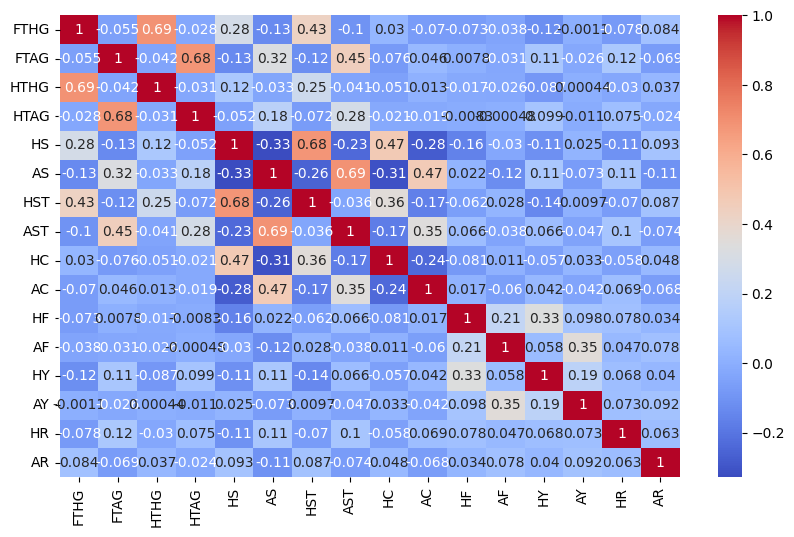

In [10]:
#visualize relationship on numerical columns
df = data[['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST',	'HC', 'AC', 'HF', 'AF',	'HY', 'AY',	'HR', 'AR']]

plt.figure(figsize = (10,6))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

# Feature Engineering

# 1. Club Form Feature Using the Past(rolling) 5 Matches Points

In [11]:
#create a column to get points per game for both home and away, where, win point = +3, draw = 1, and loss = 0
#sort by date
data = data.sort_values("DateTime")

#view the data
data[["Season", "DateTime", "HomeTeam", "AwayTeam", "FTR"]].head()

,Season,DateTime,HomeTeam,AwayTeam,FTR
0,1993-94,1993-08-14 00:00:00+00:00,Arsenal,Coventry,A
9,1993-94,1993-08-14 00:00:00+00:00,West Ham,Wimbledon,A
7,1993-94,1993-08-14 00:00:00+00:00,Sheffield United,Swindon,H
6,1993-94,1993-08-14 00:00:00+00:00,Oldham,Ipswich,A
5,1993-94,1993-08-14 00:00:00+00:00,Newcastle,Tottenham,A


In [12]:
#create a column for home points
data["HomePoints"] = data["FTR"].map({'H': 3, 'D': 1, 'A': 0}) 

#create a column for away team points
data["AwayPoints"] = data["FTR"].map({'A' : 3, 'D' : 1, 'H' : 0})

data.head()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HC,AC,HF,AF,HY,AY,HR,AR,HomePoints,AwayPoints
0,1993-94,1993-08-14 00:00:00+00:00,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
9,1993-94,1993-08-14 00:00:00+00:00,West Ham,Wimbledon,0,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
7,1993-94,1993-08-14 00:00:00+00:00,Sheffield United,Swindon,3,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
6,1993-94,1993-08-14 00:00:00+00:00,Oldham,Ipswich,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
5,1993-94,1993-08-14 00:00:00+00:00,Newcastle,Tottenham,0,1,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3


In [13]:
#view manchester united match history at home
data[data['HomeTeam'] == 'Man United']

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HC,AC,HF,AF,HY,AY,HR,AR,HomePoints,AwayPoints
18,1993-94,1993-08-18 00:00:00+00:00,Man United,Sheffield United,3,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
27,1993-94,1993-08-21 00:00:00+00:00,Man United,Newcastle,1,1,D,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
61,1993-94,1993-09-01 00:00:00+00:00,Man United,West Ham,3,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
86,1993-94,1993-09-19 00:00:00+00:00,Man United,Arsenal,1,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
93,1993-94,1993-09-25 00:00:00+00:00,Man United,Swindon,4,2,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11028,2021-22,2022-02-12 12:30:00+00:00,Man United,Southampton,1,1,D,1.0,0.0,H,...,1.0,4.0,12.0,13.0,4.0,0.0,0.0,0.0,1,1
11037,2021-22,2022-02-15 20:15:00+00:00,Man United,Brighton,2,0,H,0.0,0.0,D,...,10.0,2.0,8.0,10.0,3.0,1.0,0.0,1.0,3,0
11056,2021-22,2022-02-26 15:00:00+00:00,Man United,Watford,0,0,D,0.0,0.0,D,...,4.0,3.0,2.0,7.0,0.0,0.0,0.0,0.0,1,1
11077,2021-22,2022-03-12 17:30:00+00:00,Man United,Tottenham,3,2,H,2.0,1.0,H,...,4.0,5.0,8.0,7.0,2.0,1.0,0.0,0.0,3,0


In [14]:
#create a column to determine the rolling form of a team in the last 5 matches
data["home_form_5"] = data.groupby("HomeTeam")["HomePoints"].transform(
    lambda x: x.rolling(5).mean()
)


In [15]:
#check data info
data['home_form_5'].info()

<class 'pandas.Series'>
Index: 11113 entries, 0 to 11112
Series name: home_form_5
Non-Null Count  Dtype  
--------------  -----  
10913 non-null  float64
dtypes: float64(1)
memory usage: 173.6 KB


In [16]:
#create a column to check away team form rolling 5
data['Away_form_5'] = data.groupby('AwayTeam')['AwayPoints'].transform(lambda x: x.rolling(5).mean())
data

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HF,AF,HY,AY,HR,AR,HomePoints,AwayPoints,home_form_5,Away_form_5
0,1993-94,1993-08-14 00:00:00+00:00,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN
9,1993-94,1993-08-14 00:00:00+00:00,West Ham,Wimbledon,0,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN
7,1993-94,1993-08-14 00:00:00+00:00,Sheffield United,Swindon,3,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN
6,1993-94,1993-08-14 00:00:00+00:00,Oldham,Ipswich,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN
5,1993-94,1993-08-14 00:00:00+00:00,Newcastle,Tottenham,0,1,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,12.0,14.0,2.0,3.0,0.0,0.0,0,3,0.8,1.8
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,11.0,12.0,1.0,1.0,0.0,0.0,3,0,2.2,1.6
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,12.0,10.0,1.0,1.0,0.0,0.0,3,0,0.8,1.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,2.0,6.0,0.0,1.0,0.0,0.0,3,0,1.4,0.2


In [17]:
#aggregate the function to get the mean full time home goal
data.groupby('HomeTeam')['FTHG'].mean().sort_values()

HomeTeam
Huddersfield        0.684211
Brighton            1.032609
Burnley             1.054054
Crystal Palace      1.066079
Sheffield United    1.076923
Cardiff             1.078947
Sunderland          1.105263
Wigan               1.111842
Brentford           1.125000
Hull                1.126316
Oldham              1.142857
Derby               1.180451
Swindon             1.190476
West Brom           1.194332
Watford             1.195946
Ipswich             1.200000
Wolves              1.201342
Bradford            1.210526
Norwich             1.215116
Coventry            1.217949
Birmingham          1.218045
Reading             1.245614
Nott'm Forest       1.256410
Bolton              1.291498
QPR                 1.296610
Aston Villa         1.301619
Stoke               1.305263
Charlton            1.309211
Barnsley            1.315789
Fulham              1.333333
Swansea             1.345865
Middlesbrough       1.353383
Wimbledon           1.357664
Portsmouth          1.383459
Leice

In [18]:
#sort average to get the fulltime away goal
data.groupby('AwayTeam')['FTAG'].mean().sort_values()


AwayTeam
Bradford            0.578947
Sheffield United    0.628205
Huddersfield        0.631579
Barnsley            0.631579
Cardiff             0.657895
Hull                0.778947
Stoke               0.789474
Portsmouth          0.812030
Norwich             0.824561
Birmingham          0.834586
Oldham              0.857143
Derby               0.857143
Watford             0.859060
West Brom           0.870445
Middlesbrough       0.879699
Fulham              0.880702
Brighton            0.890110
Sunderland          0.907895
Burnley             0.912162
Ipswich             0.912500
Coventry            0.929487
Charlton            0.940789
Swansea             0.954887
Wolves              0.966443
Wigan               0.967105
West Ham            1.010101
Southampton         1.011962
Bolton              1.036437
Wimbledon           1.036496
QPR                 1.042373
Swindon             1.047619
Newcastle           1.052529
Everton             1.052632
Blackburn           1.076453
Bourn

In [19]:
#create comparison feature by comparing the home and away form in the past 5 games(rolling) to check if a team is stronger 
#than the other in the past 5 games
data['Form_diff'] = data['home_form_5'] - data['Away_form_5']
data

# NB: Positive (+) form_diff implies better home team form
# Negative (-) form diff implies better away form

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AF,HY,AY,HR,AR,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff
0,1993-94,1993-08-14 00:00:00+00:00,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN,NaN
9,1993-94,1993-08-14 00:00:00+00:00,West Ham,Wimbledon,0,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN,NaN
7,1993-94,1993-08-14 00:00:00+00:00,Sheffield United,Swindon,3,1,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN,NaN
6,1993-94,1993-08-14 00:00:00+00:00,Oldham,Ipswich,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN,NaN
5,1993-94,1993-08-14 00:00:00+00:00,Newcastle,Tottenham,0,1,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,14.0,2.0,3.0,0.0,0.0,0,3,0.8,1.8,-1.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,12.0,1.0,1.0,0.0,0.0,3,0,2.2,1.6,0.6
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,10.0,1.0,1.0,0.0,0.0,3,0,0.8,1.0,-0.2
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,6.0,0.0,1.0,0.0,0.0,3,0,1.4,0.2,1.2


In [20]:
#check columns by checking man utd form performance
data[data['HomeTeam'] == 'Man United']



,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AF,HY,AY,HR,AR,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff
18,1993-94,1993-08-18 00:00:00+00:00,Man United,Sheffield United,3,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN,NaN
27,1993-94,1993-08-21 00:00:00+00:00,Man United,Newcastle,1,1,D,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN
61,1993-94,1993-09-01 00:00:00+00:00,Man United,West Ham,3,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN,NaN
86,1993-94,1993-09-19 00:00:00+00:00,Man United,Arsenal,1,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN,NaN
93,1993-94,1993-09-25 00:00:00+00:00,Man United,Swindon,4,2,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3,0,2.6,0.4,2.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11028,2021-22,2022-02-12 12:30:00+00:00,Man United,Southampton,1,1,D,1.0,0.0,H,...,13.0,4.0,0.0,0.0,0.0,1,1,2.0,1.6,0.4
11037,2021-22,2022-02-15 20:15:00+00:00,Man United,Brighton,2,0,H,0.0,0.0,D,...,10.0,3.0,1.0,0.0,1.0,3,0,2.0,1.6,0.4
11056,2021-22,2022-02-26 15:00:00+00:00,Man United,Watford,0,0,D,0.0,0.0,D,...,7.0,0.0,0.0,0.0,0.0,1,1,1.6,1.2,0.4
11077,2021-22,2022-03-12 17:30:00+00:00,Man United,Tottenham,3,2,H,2.0,1.0,H,...,7.0,2.0,1.0,0.0,0.0,3,0,2.2,1.2,1.0


In [21]:
#check the summary statistics for the form difference
data['Form_diff'].describe()

count    10806.000000
mean         0.524412
std          1.050176
min         -3.000000
25%         -0.200000
50%          0.600000
75%          1.200000
max          3.000000
Name: Form_diff, dtype: float64

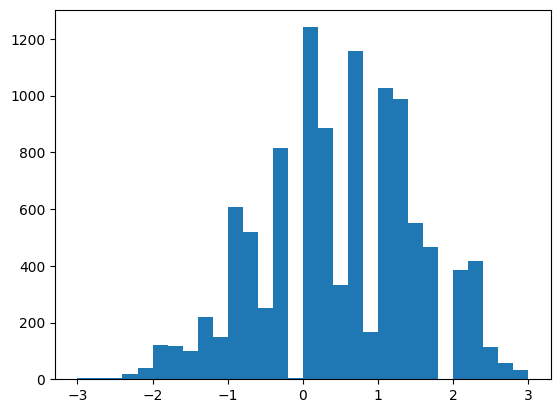

In [22]:
#visualize the form difference
plt.hist(data.Form_diff, bins = 30)
plt.show()

In [23]:
#chek the mean form of the home team in relation to the form_diff
data.groupby('HomeTeam')['Form_diff'].mean().sort_values()

#NB: Positive (+) values indicates that better home team form
#Negative (-) values indicates that better away team form

HomeTeam
Huddersfield       -0.452941
Swindon            -0.258824
Crystal Palace     -0.146364
Brentford          -0.116667
Cardiff            -0.105882
Oldham             -0.105882
Blackpool          -0.066667
Watford            -0.065734
West Brom          -0.035537
Hull               -0.028889
Brighton           -0.020455
Sheffield United   -0.002740
Norwich             0.008485
Burnley             0.009790
Bradford            0.052941
Sunderland          0.070234
Ipswich             0.082667
Wigan               0.100000
QPR                 0.105263
Bournemouth         0.113333
Wolves              0.133333
Charlton            0.220548
Derby               0.237500
Barnsley            0.240000
Swansea             0.267188
Reading             0.316981
Southampton         0.317191
Middlesbrough       0.318147
Fulham              0.335714
Aston Villa         0.336515
Leicester           0.337627
Coventry            0.343421
Wimbledon           0.350769
Portsmouth          0.356250
Bolto

In [24]:
#check the mean of the away team form in relation to the form_diff
data.groupby('AwayTeam')['Form_diff'].mean().sort_values()

#NB: Away Team with negative (-) means they often have a better form than the home team.

AwayTeam
Man United         -0.347698
Chelsea            -0.123792
Arsenal            -0.066912
Liverpool           0.005128
Man City            0.131696
Leeds               0.286667
Tottenham           0.386004
Brighton            0.530233
Aston Villa         0.543505
Everton             0.543542
Leicester           0.546939
Crystal Palace      0.566667
Blackburn           0.611987
Nott'm Forest       0.632432
Newcastle           0.634592
Swansea             0.662016
West Ham            0.680658
Wolves              0.706207
Charlton            0.708219
Southampton         0.716098
Burnley             0.719444
Wimbledon           0.736923
Sheffield Weds      0.745038
Blackpool           0.773333
Ipswich             0.784211
Bournemouth         0.784615
Bolton              0.810833
Wigan               0.813699
Middlesbrough       0.820000
Stoke               0.835676
Coventry            0.851351
West Brom           0.885000
Oldham              0.894118
Brentford           0.900000
Fulha

# Attacking Feature (Goal Strength) Using the 5 Past Matches

In [25]:
#sort data by datetime
data = data.sort_values(by = 'DateTime')
data.head()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AF,HY,AY,HR,AR,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff
0,1993-94,1993-08-14 00:00:00+00:00,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN,NaN
4,1993-94,1993-08-14 00:00:00+00:00,Man City,Leeds,1,1,D,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN
2,1993-94,1993-08-14 00:00:00+00:00,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN,NaN
3,1993-94,1993-08-14 00:00:00+00:00,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN,NaN
8,1993-94,1993-08-14 00:00:00+00:00,Southampton,Everton,0,2,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,3,NaN,NaN,NaN


In [26]:
# create Home_goal_scored_5 column for the rolling 5 
data['Home_goal_scored_5'] = data.groupby('HomeTeam')['FTHG'].transform(lambda x: x.rolling(5).sum())
data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff,Home_goal_scored_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,2.0,3.0,0.0,0.0,0,3,0.8,1.8,-1.0,7.0
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,1.0,1.0,0.0,0.0,3,0,0.8,1.0,-0.2,5.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,0.0,1.0,0.0,0.0,3,0,1.4,0.2,1.2,5.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,1.0,1.0,0.0,0.0,3,0,2.2,1.6,0.6,8.0
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,1.0,4.0,0.0,0.0,1,1,2.0,2.6,-0.6,11.0


In [27]:
# do the same to get how the team perform in away games
data['Away_goal_scored_5'] = data.groupby('AwayTeam')['FTAG'].transform(lambda x: x.rolling(5).sum())
data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AY,HR,AR,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff,Home_goal_scored_5,Away_goal_scored_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,3.0,0.0,0.0,0,3,0.8,1.8,-1.0,7.0,12.0
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,1.0,0.0,0.0,3,0,0.8,1.0,-0.2,5.0,4.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,1.0,0.0,0.0,3,0,1.4,0.2,1.2,5.0,3.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,1.0,0.0,0.0,3,0,2.2,1.6,0.6,8.0,8.0
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,4.0,0.0,0.0,1,1,2.0,2.6,-0.6,11.0,10.0


In [28]:
#evaluate the goal conceded for the home team for each past 5 games
#This gives information about how strong the defense is at home
data['Home_concede_5'] = data.groupby('HomeTeam')['FTAG'].transform(lambda x: x.rolling(5).sum())
data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HR,AR,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff,Home_goal_scored_5,Away_goal_scored_5,Home_concede_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,0.0,0.0,0,3,0.8,1.8,-1.0,7.0,12.0,9.0
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,0.0,0.0,3,0,0.8,1.0,-0.2,5.0,4.0,11.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,0.0,0.0,3,0,1.4,0.2,1.2,5.0,3.0,4.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,0.0,0.0,3,0,2.2,1.6,0.6,8.0,8.0,5.0
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,0.0,0.0,1,1,2.0,2.6,-0.6,11.0,10.0,6.0


In [29]:
#do the same for Away team to know how strong the defense is 
data['Away_concede_5'] = data.groupby('AwayTeam')['FTHG'].transform(lambda x: x.rolling(5).sum())
data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AR,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff,Home_goal_scored_5,Away_goal_scored_5,Home_concede_5,Away_concede_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,0.0,0,3,0.8,1.8,-1.0,7.0,12.0,9.0,4.0
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,0.0,3,0,0.8,1.0,-0.2,5.0,4.0,11.0,5.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,0.0,3,0,1.4,0.2,1.2,5.0,3.0,4.0,9.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,0.0,3,0,2.2,1.6,0.6,8.0,8.0,5.0,4.0
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,0.0,1,1,2.0,2.6,-0.6,11.0,10.0,6.0,3.0


In [30]:
#evaluate total goals socored by a team in the past 5 games: gives the net attacking and defense information of a team
data['Home_goal_diff_5'] = data['Home_goal_scored_5'] - data['Home_concede_5']
data.tail()


,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HomePoints,AwayPoints,home_form_5,Away_form_5,Form_diff,Home_goal_scored_5,Away_goal_scored_5,Home_concede_5,Away_concede_5,Home_goal_diff_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,0,3,0.8,1.8,-1.0,7.0,12.0,9.0,4.0,-2.0
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,3,0,0.8,1.0,-0.2,5.0,4.0,11.0,5.0,-6.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,3,0,1.4,0.2,1.2,5.0,3.0,4.0,9.0,1.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,3,0,2.2,1.6,0.6,8.0,8.0,5.0,4.0,3.0
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,1,1,2.0,2.6,-0.6,11.0,10.0,6.0,3.0,5.0


In [31]:
#evaluate the total goals by away team to know their attacking and defence strength
data['Away_goal_diff_5'] = data['Away_goal_scored_5'] - data['Away_concede_5']
data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AwayPoints,home_form_5,Away_form_5,Form_diff,Home_goal_scored_5,Away_goal_scored_5,Home_concede_5,Away_concede_5,Home_goal_diff_5,Away_goal_diff_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,3,0.8,1.8,-1.0,7.0,12.0,9.0,4.0,-2.0,8.0
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,0,0.8,1.0,-0.2,5.0,4.0,11.0,5.0,-6.0,-1.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,0,1.4,0.2,1.2,5.0,3.0,4.0,9.0,1.0,-6.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,0,2.2,1.6,0.6,8.0,8.0,5.0,4.0,3.0,4.0
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,1,2.0,2.6,-0.6,11.0,10.0,6.0,3.0,5.0,7.0


<function matplotlib.pyplot.show(close=None, block=None)>

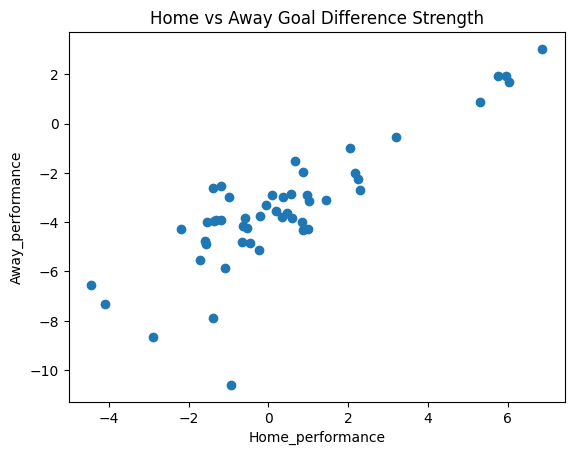

In [32]:
#visualize the relationship between the away goal difference and home goal difference to see the defense and attacking strength of a team
home = data.groupby('HomeTeam')['Home_goal_diff_5'].mean()
away = data.groupby('AwayTeam')['Away_goal_diff_5'].mean()

#convert to df for proper indexing
team_df = pd.DataFrame({"home": home,
                        "away":away}).dropna()

plt.scatter(team_df["home"], team_df["away"])
plt.xlabel('Home_performance')
plt.ylabel('Away_performance')
plt.title('Home vs Away Goal Difference Strength')
plt.show


In [33]:
# create a column to goal_strength_diff to compare the current competing teams goals in the previous games using the total goals scored in the previous games.
#this tells us the performance of the cometing team in terms of defence, and attack
data['Goal_diff_strength'] = data['Home_goal_diff_5'] - data['Away_goal_diff_5']
data.tail()

#NB: Negative (-) signifies Away team creates more attacking threat
# Positive (+) signifies Home team creates more attacking threat

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,home_form_5,Away_form_5,Form_diff,Home_goal_scored_5,Away_goal_scored_5,Home_concede_5,Away_concede_5,Home_goal_diff_5,Away_goal_diff_5,Goal_diff_strength
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,0.8,1.8,-1.0,7.0,12.0,9.0,4.0,-2.0,8.0,-10.0
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,0.8,1.0,-0.2,5.0,4.0,11.0,5.0,-6.0,-1.0,-5.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,1.4,0.2,1.2,5.0,3.0,4.0,9.0,1.0,-6.0,7.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,2.2,1.6,0.6,8.0,8.0,5.0,4.0,3.0,4.0,-1.0
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,2.0,2.6,-0.6,11.0,10.0,6.0,3.0,5.0,7.0,-2.0


# 2. Shots Feature
- to determine attack and defense strength of a team


In [34]:
#create a column for home shots and shots on target
data['Home_shots_5'] = data.groupby('HomeTeam')['HS'].transform(lambda x: x.rolling(5).mean())

data['HS_on_target_5'] = data.groupby('HomeTeam')['HST'].transform(lambda x: x.rolling(5).mean())

data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Form_diff,Home_goal_scored_5,Away_goal_scored_5,Home_concede_5,Away_concede_5,Home_goal_diff_5,Away_goal_diff_5,Goal_diff_strength,Home_shots_5,HS_on_target_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,-1.0,7.0,12.0,9.0,4.0,-2.0,8.0,-10.0,12.6,4.6
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,-0.2,5.0,4.0,11.0,5.0,-6.0,-1.0,-5.0,10.8,4.0
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,1.2,5.0,3.0,4.0,9.0,1.0,-6.0,7.0,10.8,3.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,0.6,8.0,8.0,5.0,4.0,3.0,4.0,-1.0,11.8,3.6
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,-0.6,11.0,10.0,6.0,3.0,5.0,7.0,-2.0,16.4,6.4


In [35]:
#create a column for Away shots and shots on target
data['Away_shots_5'] = data.groupby('AwayTeam')['AS'].transform(lambda x: x.rolling(5).mean())

data['AS_on_target_5'] = data.groupby('AwayTeam')['AST'].transform(lambda x: x.rolling(5).mean())

data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Away_goal_scored_5,Home_concede_5,Away_concede_5,Home_goal_diff_5,Away_goal_diff_5,Goal_diff_strength,Home_shots_5,HS_on_target_5,Away_shots_5,AS_on_target_5
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,12.0,9.0,4.0,-2.0,8.0,-10.0,12.6,4.6,13.0,5.6
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,4.0,11.0,5.0,-6.0,-1.0,-5.0,10.8,4.0,10.0,2.2
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,3.0,4.0,9.0,1.0,-6.0,7.0,10.8,3.0,7.6,2.2
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,8.0,5.0,4.0,3.0,4.0,-1.0,11.8,3.6,9.8,4.8
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,10.0,6.0,3.0,5.0,7.0,-2.0,16.4,6.4,12.0,5.4


In [36]:
#create a column for attacking strength by adding total shots
data['Home_Attack_str'] = (data['Home_shots_5'] + data['HS_on_target_5']) / 2
data['Away_attack_str'] = (data['Away_shots_5'] + data['AS_on_target_5']) / 2

data.tail()

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Away_concede_5,Home_goal_diff_5,Away_goal_diff_5,Goal_diff_strength,Home_shots_5,HS_on_target_5,Away_shots_5,AS_on_target_5,Home_Attack_str,Away_attack_str
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,4.0,-2.0,8.0,-10.0,12.6,4.6,13.0,5.6,8.6,9.3
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,5.0,-6.0,-1.0,-5.0,10.8,4.0,10.0,2.2,7.4,6.1
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,9.0,1.0,-6.0,7.0,10.8,3.0,7.6,2.2,6.9,4.9
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,4.0,3.0,4.0,-1.0,11.8,3.6,9.8,4.8,7.7,7.3
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,3.0,5.0,7.0,-2.0,16.4,6.4,12.0,5.4,11.4,8.7


In [37]:
#create a column for attacking comparison of the competing teams
data['Attack_diff'] = data['Home_Attack_str'] - data['Away_attack_str']
data.tail()

#NB: Negative implies away team is more strong in respect to attack
#Positive implies Home team is more strong in respect to attack

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Home_goal_diff_5,Away_goal_diff_5,Goal_diff_strength,Home_shots_5,HS_on_target_5,Away_shots_5,AS_on_target_5,Home_Attack_str,Away_attack_str,Attack_diff
11108,2021-22,2022-04-09 17:30:00+00:00,Aston Villa,Tottenham,0,4,A,0.0,1.0,A,...,-2.0,8.0,-10.0,12.6,4.6,13.0,5.6,8.6,9.3,-0.7
11111,2021-22,2022-04-10 14:00:00+00:00,Norwich,Burnley,2,0,H,1.0,0.0,H,...,-6.0,-1.0,-5.0,10.8,4.0,10.0,2.2,7.4,6.1,1.3
11109,2021-22,2022-04-10 14:00:00+00:00,Brentford,West Ham,2,0,H,0.0,0.0,D,...,1.0,-6.0,7.0,10.8,3.0,7.6,2.2,6.9,4.9,2.0
11110,2021-22,2022-04-10 14:00:00+00:00,Leicester,Crystal Palace,2,1,H,2.0,0.0,H,...,3.0,4.0,-1.0,11.8,3.6,9.8,4.8,7.7,7.3,0.4
11112,2021-22,2022-04-10 16:30:00+00:00,Man City,Liverpool,2,2,D,2.0,1.0,H,...,5.0,7.0,-2.0,16.4,6.4,12.0,5.4,11.4,8.7,2.7


In [38]:
#ceate a feature for tight_match: this feature will help model increase probability of draw... 
#extreme value of tight_match implies one team is very strong, while low value increases the probability of draw
data["tight_match"] = abs(data['Goal_diff_strength'])
data.head

<bound method NDFrame.head of         Season                  DateTime     HomeTeam        AwayTeam  FTHG  \
0      1993-94 1993-08-14 00:00:00+00:00      Arsenal        Coventry     0   
4      1993-94 1993-08-14 00:00:00+00:00     Man City           Leeds     1   
2      1993-94 1993-08-14 00:00:00+00:00      Chelsea       Blackburn     1   
3      1993-94 1993-08-14 00:00:00+00:00    Liverpool  Sheffield Weds     2   
8      1993-94 1993-08-14 00:00:00+00:00  Southampton         Everton     0   
...        ...                       ...          ...             ...   ...   
11108  2021-22 2022-04-09 17:30:00+00:00  Aston Villa       Tottenham     0   
11111  2021-22 2022-04-10 14:00:00+00:00      Norwich         Burnley     2   
11109  2021-22 2022-04-10 14:00:00+00:00    Brentford        West Ham     2   
11110  2021-22 2022-04-10 14:00:00+00:00    Leicester  Crystal Palace     2   
11112  2021-22 2022-04-10 16:30:00+00:00     Man City       Liverpool     2   

       FTAG FTR  HTHG

In [39]:
print(data.groupby("FTR")["Attack_diff"].mean())
data["Attack_diff"].describe()

FTR
A    0.518263
D    1.917254
H    3.237497
Name: Attack_diff, dtype: float64


count    8020.000000
mean        2.113791
std         3.321723
min        -8.700000
25%        -0.100000
50%         2.100000
75%         4.300000
max        14.700000
Name: Attack_diff, dtype: float64

In [40]:
#check the data shape
data.shape

(11113, 43)

In [41]:
#drop null values
data = data.dropna()
print(data.shape)
data.head()

(8020, 43)


,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Away_goal_diff_5,Goal_diff_strength,Home_shots_5,HS_on_target_5,Away_shots_5,AS_on_target_5,Home_Attack_str,Away_attack_str,Attack_diff,tight_match
2903,2000-01,2000-10-14 00:00:00+00:00,Arsenal,Aston Villa,1,0,H,0.0,0.0,D,...,-2.0,9.0,15.2,9.8,8.4,3.8,12.5,6.1,6.4,9.0
2904,2000-01,2000-10-14 00:00:00+00:00,Coventry,Tottenham,2,1,H,2.0,0.0,H,...,-5.0,-1.0,7.4,2.8,9.0,4.2,5.1,6.6,-1.5,1.0
2905,2000-01,2000-10-14 00:00:00+00:00,Everton,Southampton,1,1,D,0.0,0.0,D,...,0.0,-2.0,9.0,5.4,9.2,4.4,7.2,6.8,0.4,2.0
2906,2000-01,2000-10-14 00:00:00+00:00,Ipswich,West Ham,1,1,D,1.0,0.0,H,...,0.0,0.0,14.0,6.4,11.6,6.2,10.2,8.9,1.3,0.0
2907,2000-01,2000-10-14 00:00:00+00:00,Leeds,Charlton,3,1,H,1.0,0.0,H,...,-6.0,9.0,14.0,6.4,7.8,4.8,10.2,6.3,3.9,9.0


# Feature Selection and Modelling

In [78]:
#import the required libraries
#!pip install xgboost
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [79]:
#list all columns
data.columns

Index(['Season', 'DateTime', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC',
       'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'HomePoints', 'AwayPoints',
       'home_form_5', 'Away_form_5', 'Form_diff', 'Home_goal_scored_5',
       'Away_goal_scored_5', 'Home_concede_5', 'Away_concede_5',
       'Home_goal_diff_5', 'Away_goal_diff_5', 'Goal_diff_strength',
       'Home_shots_5', 'HS_on_target_5', 'Away_shots_5', 'AS_on_target_5',
       'Home_Attack_str', 'Away_attack_str', 'Attack_diff', 'tight_match'],
      dtype='str')

In [80]:
#select feature for modelling drop other columns
model_feature = data.drop(columns = ['Season', 'DateTime','HomeTeam', 'AwayTeam',
                                     'HTHG', 'FTHG', 'FTAG', 'HTAG', 'HTR', 'Referee', 
                                     'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 
                                     'HR', 'AR', 'HomePoints','AwayPoints'])

print(model_feature.columns)
print(model_feature.shape)

Index(['FTR', 'HS', 'AS', 'HST', 'AST', 'home_form_5', 'Away_form_5',
       'Form_diff', 'Home_goal_scored_5', 'Away_goal_scored_5',
       'Home_concede_5', 'Away_concede_5', 'Home_goal_diff_5',
       'Away_goal_diff_5', 'Goal_diff_strength', 'Home_shots_5',
       'HS_on_target_5', 'Away_shots_5', 'AS_on_target_5', 'Home_Attack_str',
       'Away_attack_str', 'Attack_diff', 'tight_match'],
      dtype='str')
(8020, 23)


In [81]:
#select independent and response variable
X = model_feature.drop(columns = 'FTR')
y = model_feature['FTR']

In [82]:
#label encoding
le = LabelEncoder()
le.fit(y)
y_encoded = le.transform(y)

#for original, encoded in zip(le.inverse_transform(y_encoded), y_encoded):
    #print(original, "=>", encoded)
# H: 2,
# D: 1,
# A: 0

In [83]:
#=====DATA PREPROCESSING=====
#split the data into test and train sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y_encoded, test_size = 0.2, random_state = 42, stratify = y_encoded)



In [102]:
#====MODELLING=====
#instantiate the model
model = GradientBoostingClassifier(n_estimators = 500,
                                   learning_rate = 0.05,
                                   max_depth = 2,
                                   subsample = 0.8)
                               

#fit the model
model.fit(X1_train, y1_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [103]:
#model evaluaion
y_pred = model.predict(X1_test)

report = classification_report(y1_test, y_pred)
print(report)
matrix = confusion_matrix(y1_test, y_pred)
print(matrix)

              precision    recall  f1-score   support

           0       0.70      0.74      0.72       470
           1       0.54      0.42      0.48       398
           2       0.75      0.82      0.78       736

    accuracy                           0.70      1604
   macro avg       0.67      0.66      0.66      1604
weighted avg       0.69      0.70      0.69      1604

[[348  59  63]
 [ 96 169 133]
 [ 51  83 602]]


In [104]:
importance = model.feature_importances_
feature_importance = pd.Series(importance, index = X.columns).sort_values()
feature_importance

Home_goal_scored_5    0.005728
Away_goal_scored_5    0.005908
Away_shots_5          0.006154
Away_attack_str       0.006651
Home_Attack_str       0.007663
Home_shots_5          0.008860
Goal_diff_strength    0.009822
Away_concede_5        0.009972
Away_goal_diff_5      0.010850
AS_on_target_5        0.011605
Home_goal_diff_5      0.012467
AS                    0.013145
Attack_diff           0.014777
Home_concede_5        0.015453
HS_on_target_5        0.015560
HS                    0.016498
tight_match           0.026694
HST                   0.050885
AST                   0.051374
Away_form_5           0.056977
home_form_5           0.066277
Form_diff             0.576679
dtype: float64

In [105]:
print(model.score(X1_train, y1_train))
print(model.score(X1_test, y1_test))

0.7417394014962594
0.6976309226932669


### Retrain model without form_diff feature

In [53]:
# model is too dependent on form_diff retrain with out form_diff column
#select feature for modelling drop other columns
model_feature = data.drop(columns = ['Season', 'DateTime','HomeTeam', 'AwayTeam',
                                     'HTHG', 'FTHG', 'FTAG', 'HTAG', 'HTR', 'Referee', 
                                     'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 
                                     'HR', 'AR', 'HomePoints','AwayPoints', 'Form_diff'])

print(model_feature.columns)
print(model_feature.shape)

Index(['FTR', 'HS', 'AS', 'HST', 'AST', 'home_form_5', 'Away_form_5',
       'Home_goal_scored_5', 'Away_goal_scored_5', 'Home_concede_5',
       'Away_concede_5', 'Home_goal_diff_5', 'Away_goal_diff_5',
       'Goal_diff_strength', 'Home_shots_5', 'HS_on_target_5', 'Away_shots_5',
       'AS_on_target_5', 'Home_Attack_str', 'Away_attack_str', 'Attack_diff',
       'tight_match'],
      dtype='str')
(8020, 22)


In [54]:
#select independent and response variable
X = model_feature.drop(columns = 'FTR')
y = model_feature['FTR']

In [55]:
#label encoding
le = LabelEncoder()
le.fit(y)
y_encoded = le.transform(y)

#for original, encoded in zip(le.inverse_transform(y_encoded), y_encoded):
    #print(original, "=>", encoded)
# H: 2,
# D: 1,
# A: 0

In [56]:
#=====DATA PREPROCESSING=====
#split the data into test and train sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2, random_state = 42, stratify = y_encoded)

In [57]:
#====MODELLING=====
#instantiate the model
model_2 = GradientBoostingClassifier(n_estimators = 500,
                                   learning_rate = 0.05,
                                   max_depth = 4,
                                   subsample = 0.8)
                               

#fit the model
model_2.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [359]:
#model evaluaion
y_pred_2 = model_2.predict(X_test)

report = classification_report(y_test, y_pred_2)
print(report)
matrix = confusion_matrix(y_test, y_pred_2)
print(matrix)

              precision    recall  f1-score   support

           0       0.71      0.76      0.74       456
           1       0.56      0.43      0.49       385
           2       0.75      0.82      0.79       710

    accuracy                           0.70      1551
   macro avg       0.68      0.67      0.67      1551
weighted avg       0.69      0.70      0.70      1551

[[347  54  55]
 [ 86 165 134]
 [ 55  74 581]]


In [360]:
importance_2 = model_2.feature_importances_
feature_importance_2 = pd.Series(importance_2, index = X.columns).sort_values()
feature_importance_2

Home_goal_scored_5    0.015667
Away_goal_scored_5    0.016591
Home_concede_5        0.022508
Away_attack_str       0.022656
AS_on_target_5        0.023205
Away_shots_5          0.023501
Away_concede_5        0.024131
Home_goal_diff_5      0.024652
AS                    0.024939
HS                    0.026344
Away_goal_diff_5      0.026352
Home_Attack_str       0.026758
HS_on_target_5        0.027295
Home_shots_5          0.027877
Attack_diff           0.030674
AST                   0.045528
HST                   0.047070
tight_match           0.048153
Away_form_5           0.124534
home_form_5           0.136604
Goal_diff_strength    0.234960
dtype: float64

## Final model with XGBoost

In [106]:
#===MODELLING WITH XGBOOST
#instantate the model
xgb_model = XGBClassifier(n_estimators = 500,
                          learning_rate = 0.05,
                          max_depth = 2,
                          subsample = 0.8,
                          colsample_bytree = 0.7)
#fit the model
xgb_model.fit(X1_train, y1_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [111]:
#predict and evaluate
y_pred_ = xgb_model.predict(X1_test)

#model evaluation
xgb_report = classification_report(y1_test, y_pred_)
print("Classification_report:\n",xgb_report)

xgb_matrix = confusion_matrix(y1_test, y_pred_)
print("Confusion_matrix:\n",xgb_matrix)

Classification_report:
               precision    recall  f1-score   support

           0       0.70      0.75      0.72       470
           1       0.54      0.37      0.44       398
           2       0.74      0.83      0.78       736

    accuracy                           0.69      1604
   macro avg       0.66      0.65      0.65      1604
weighted avg       0.68      0.69      0.68      1604

Confusion_matrix:
 [[353  53  64]
 [102 149 147]
 [ 52  76 608]]


In [112]:
#check feature importance
importance_ = xgb_model.feature_importances_
feature_importance_ = pd.Series(importance_, index = X.columns)
feature_importance_

HS                    0.018551
AS                    0.016575
HST                   0.035021
AST                   0.042936
home_form_5           0.045857
Away_form_5           0.047062
Form_diff             0.314985
Home_goal_scored_5    0.015346
Away_goal_scored_5    0.014512
Home_concede_5        0.028669
Away_concede_5        0.022611
Home_goal_diff_5      0.030500
Away_goal_diff_5      0.027986
Goal_diff_strength    0.133404
Home_shots_5          0.016012
HS_on_target_5        0.020514
Away_shots_5          0.015850
AS_on_target_5        0.018771
Home_Attack_str       0.018850
Away_attack_str       0.015520
Attack_diff           0.019133
tight_match           0.081333
dtype: float32

In [110]:
print(xgb_model.score(X1_train, y1_train))
print(xgb_model.score(X1_test, y1_test))

0.7247506234413965
0.6920199501246883


## in conclusion, Gradient Boosting learns well than XGBoost

# Serialization

In [115]:
import pickle 
#serialize the model
model_save_path = "epl_model.pkl"
with open (model_save_path, 'wb') as file:
    pickle.dump(model, file)

#serilizing the encoder
encoder_save_path = "label_encoder.pkl"
with open (encoder_save_path, 'wb') as file:
    pickle.dump(le, file)

#serilizing the columns 
col_save_path = "features.pkl"
with open (col_save_path, 'wb') as file:
    pickle.dump(X.columns.tolist(), file)

In [364]:
print(X.columns.tolist())

['HS', 'AS', 'HST', 'AST', 'home_form_5', 'Away_form_5', 'Home_goal_scored_5', 'Away_goal_scored_5', 'Home_concede_5', 'Away_concede_5', 'Home_goal_diff_5', 'Away_goal_diff_5', 'Goal_diff_strength', 'Home_shots_5', 'HS_on_target_5', 'Away_shots_5', 'AS_on_target_5', 'Home_Attack_str', 'Away_attack_str', 'Attack_diff', 'tight_match']
